In [1]:
import tensorflow_datasets as tfds
import tqdm
import numpy as np
from PIL import Image
from IPython import display
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
def as_gif(images, path='temp.gif'):
  # Render the images as the gif:
  images[0].save(path, save_all=True, append_images=images[1:], duration=1000, loop=0)
  gif_bytes = open(path,'rb').read()
  return gif_bytes

dict_keys(['wrist_image', 'natural_language_embedding', 'robot_state', 'image', 'natural_language_instruction'])


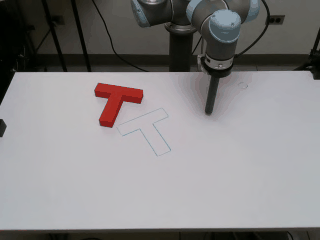

In [3]:
PATH = "C:\\Users\\Simo\\Documents\\tf_datasets\\columbia_cairlab_pusht_real\\0.1.0"
display_key = 'image'

b = tfds.builder_from_directory(builder_dir=PATH)
print(b.info.features['steps']['observation'].keys())

if display_key not in b.info.features['steps']['observation']:
  raise ValueError(
      f"The key {display_key} was not found in this dataset.\n"
      + "Please choose a different image key to display for this dataset.\n"
      + "Here is the observation spec:\n"
      + str(b.info.features['steps']['observation']))

ds = b.as_dataset(split='train[:10]').shuffle(10)   # take only first 10 episodes
episode = next(iter(ds))
images = [step['observation'][display_key] for step in episode['steps']]
images = [Image.fromarray(image.numpy()) for image in images]
display.Image(as_gif(images))

In [4]:
type(episode["steps"])
card = episode["steps"].cardinality()
print(card)  # may be a scalar tensor or special value

# In eager mode (TF 2.x) to get a Python int:
length = card.numpy()
print("Length:", length)

tf.Tensor(163, shape=(), dtype=int64)
Length: 163


In [5]:
it = iter(episode["steps"])

In [6]:
step = next(it)
print(step.keys())
print(step["observation"].keys())
print(step["observation"]["image"].shape)
print(step["observation"]["natural_language_instruction"])
print(step["action"].keys())
#print(step["action"]['base_displacement_vector'])
#print(step["action"]['base_displacement_vertical_rotation'])
print(step["action"]['gripper_closedness_action'])
print(step["action"]['rotation_delta'])
print(step["action"]["world_vector"])

#print(dict["action"])
#print(dict["observation"]["effector_target_translation"])
#print(dict["observation"]["effector_translation"])

dict_keys(['action', 'is_first', 'is_last', 'is_terminal', 'observation', 'reward'])
dict_keys(['image', 'natural_language_embedding', 'natural_language_instruction', 'robot_state', 'wrist_image'])
(240, 320, 3)
tf.Tensor(b'The task requires pushing a T-shaped block (gray) to a fixed target (green) with a circular end-effector (blue). Both observation and control frequencies are 10Hz.', shape=(), dtype=string)
dict_keys(['gripper_closedness_action', 'rotation_delta', 'terminate_episode', 'world_vector'])
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor([0. 0. 0.], shape=(3,), dtype=float32)
tf.Tensor([-2.3572918e-04  3.4655208e-05  0.0000000e+00], shape=(3,), dtype=float32)


In [7]:
# Load builder from local directory
builder = tfds.builder_from_directory(builder_dir=PATH)

# Full train split; you can slice if you want (e.g. "train[:10]")
ds = builder.as_dataset(split="train")

episodes_displacements = {}  # ep_idx -> dict with 'instruction' and 'displacements'

for ep_idx, episode in enumerate(ds):
    # episode["steps"] is a tf.data.Dataset of step dicts
    step_ds = episode["steps"]

    disps = []

    # Convert steps to numpy for easy use
    for step in tfds.as_numpy(step_ds):
      # world_vector is shape (3,) float32: [dx, dy, dz]
        dv = step["action"]["world_vector"]  # numpy array of shape (3,)
        disps.append(dv)

    # Convert list of (3,) arrays to (T, 3) array
    disps = np.stack(disps, axis=0)  # shape (T, 3)

    episodes_displacements[ep_idx] = disps


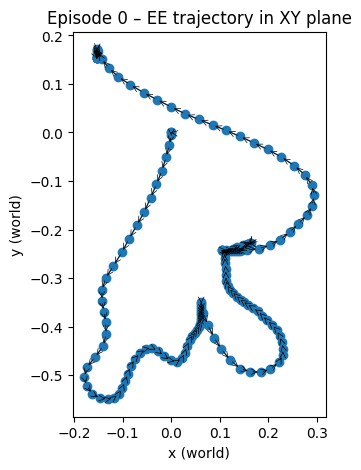

In [9]:
ep_idx = 0  # choose any valid episode index
disps = episodes_displacements[ep_idx]   # shape (T, 3), [dx, dy, dz]

# Reconstruct positions from displacements, starting at origin
positions = np.cumsum(disps, axis=0)      # (T, 3)
positions = np.vstack([np.zeros(3), positions])  # (T+1, 3) include start at (0,0,0)

# 2D XY trajectory
x = positions[:, 0]
y = positions[:, 1]

fig, ax = plt.subplots(figsize=(5, 5))

# Plot the path
ax.plot(x, y, marker='o', linewidth=1)

# Add arrows between successive points to show direction
for i in range(len(x) - 1):
    ax.annotate(
        '',
        xy=(x[i + 1], y[i + 1]),
        xytext=(x[i], y[i]),
        arrowprops=dict(arrowstyle='->', lw=0.5),
    )

ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("x (world)")
ax.set_ylabel("y (world)")
ax.set_title(f"Episode {ep_idx} – EE trajectory in XY plane")

plt.show()

In [30]:
def disps_to_positions(disps):
    """
    disps: (T, 3) or (T, 2)
    returns positions: (T+1, D) with pos[0] = 0
    """
    # cumulative sum of displacements
    pos = np.concatenate(
        [np.zeros((1, disps.shape[1]), dtype=disps.dtype),
         np.cumsum(disps, axis=0)],
        axis=0
    )
    return pos

def rdp_segment_indices(points, eps):
    """
    points: (N, 2) or (N, 3)
    eps: max allowed perpendicular distance
    return: sorted list of indices to KEEP (key points), at least [0, N-1]
    """
    N = points.shape[0]
    
    def _rdp_rec(start, end, keep):
        if end <= start + 1:
            return
        
        p_start = points[start]
        p_end   = points[end]
        seg = p_end - p_start
        seg_norm = np.linalg.norm(seg)
        
        if seg_norm < 1e-9:
            # nearly identical points
            return
        
        # perpendicular distances to segment
        v = points[start+1:end] - p_start  # (M, D)
        # projection length (scalar) onto seg
        t = np.dot(v, seg) / (seg_norm**2)
        proj = np.outer(t, seg)            # (M, D)
        perp = v - proj
        dists = np.linalg.norm(perp, axis=1)
        
        max_idx = np.argmax(dists)
        max_dist = dists[max_idx]
        
        if max_dist > eps:
            # split at this point
            idx = start + 1 + max_idx
            keep.add(idx)
            _rdp_rec(start, idx, keep)
            _rdp_rec(idx, end, keep)
        else:
            # no need to split; straight enough
            return
    
    keep = {0, N-1}
    _rdp_rec(0, N-1, keep)
    return sorted(list(keep))

def segments_from_key_idxs(key_idxs, T):
    """
    key_idxs: indices over positions (0..T)
    T: number of displacements (positions length = T+1)
    returns: list of (start_t, end_t) for displacements
             where each segment is disps[start_t:end_t]  (end_t exclusive)
    """
    segments = []
    for a, b in zip(key_idxs[:-1], key_idxs[1:]):
        start_t = a
        end_t   = b  # because disps[t] moves from pos[t] -> pos[t+1]
        segments.append((start_t, end_t))
    return segments

def filter_segments(segments, disps,
                    min_len=5,
                    min_total_disp=0.01):
    """
    Remove tiny or too-short segments.
    disps: (T, 3)
    segments: list of (s,e)
    """
    good = []
    for (s, e) in segments:
        L = e - s
        if L < min_len:
            continue
        disp_vec = disps[s:e, :2].sum(axis=0)
        if np.linalg.norm(disp_vec) < min_total_disp:
            continue
        good.append((s, e))
    return good

def segment_direction_ok(disps, s, e, max_angle_deg=60):
    """
    Check that direction doesn't change too abruptly inside segment.
    """
    v = disps[s:e, :2]  # 2D
    norms = np.linalg.norm(v, axis=1, keepdims=True) + 1e-9
    u = v / norms
    dots = (u[:-1] * u[1:]).sum(axis=1)
    dots = np.clip(dots, -1.0, 1.0)
    angles = np.degrees(np.arccos(dots))
    return np.max(angles) <= max_angle_deg

def plot_trajectory_segments(disps, segments, title=None):
    """
    disps: (T, 3) array for a single episode
    segments: list of (start_t, end_t) indices
    """
    # Work in 2D for PushT
    pos = disps_to_positions(disps[:, :2])  # (T+1, 2)

    plt.figure(figsize=(6, 6))

    # Plot full trajectory (light)
    plt.plot(pos[:, 0], pos[:, 1], linestyle='--', alpha=0.3, label='full traj')

    # Color map for segments
    cmap = plt.get_cmap('tab20')
    num_seg = len(segments)

    for i, (s, e) in enumerate(segments):
        seg_pos = pos[s:e+1]  # positions along this segment
        color = cmap(i % 20)

        plt.plot(seg_pos[:, 0], seg_pos[:, 1], linewidth=2.5, color=color)

        # Mark start & end
        plt.scatter(seg_pos[0, 0], seg_pos[0, 1], marker='o', color=color)
        plt.scatter(seg_pos[-1, 0], seg_pos[-1, 1], marker='x', color=color)

        # Label segment id at its midpoint
        mid_idx = (s + e) // 2
        mid_pos = pos[mid_idx]
        plt.text(mid_pos[0], mid_pos[1], str(i),
                 fontsize=9, color=color,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.7))

    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel('x (world)')
    plt.ylabel('y (world)')
    if title is not None:
        plt.title(title)
    else:
        plt.title('Trajectory with segmented subtrajectories')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def visualize_episode_segments(episodes_displacements,
                               ep_idx,
                               eps=0.01,
                               filter=True,
                               enforce_smooth=True,
                               min_len=5,
                               min_total_disp=0.01,
                               max_angle_deg=60):
    """
    episodes_displacements: dict[ep_idx] -> (T, 3)
    ep_idx: which episode to visualize
    """
    disps = episodes_displacements[ep_idx]  # (T, 3)

    # Positions for RDP (2D)
    positions = disps_to_positions(disps[:, :2])  # (T+1, 2)

    # 1) RDP to get keypoints
    key_idxs = rdp_segment_indices(positions, eps=eps)

    # 2) raw segments
    T = disps.shape[0]
    segments = segments_from_key_idxs(key_idxs, T)
    print("segments legth before filtering:", len(segments))

    if filter:
    # 3) filter small/weak segments
        segments = filter_segments(segments, disps,
                                min_len=min_len,
                                min_total_disp=min_total_disp)
        print("segments length after filtering:", len(segments))

    if enforce_smooth:
        # 4) enforce direction smoothness
        final_segments = []
        for s, e in segments:
            if segment_direction_ok(disps, s, e, max_angle_deg=max_angle_deg):
                final_segments.append((s, e))
        segments = final_segments
        print("segments length after direction filtering:", len(segments))

    # 5) visualize
    title = f"Episode {ep_idx} — {len(segments)} segments"
    plot_trajectory_segments(disps, segments, title=title)



segments legth before filtering: 33


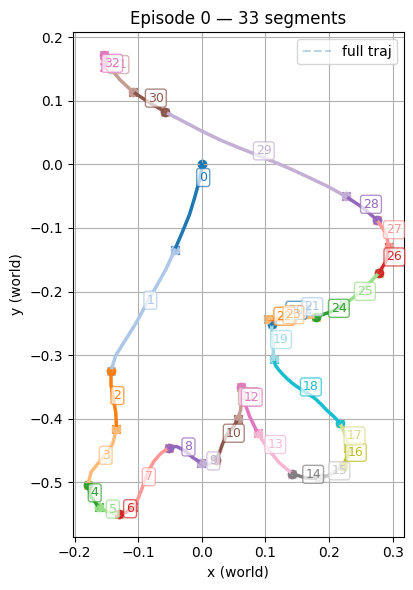

segments legth before filtering: 33
segments length after filtering: 12


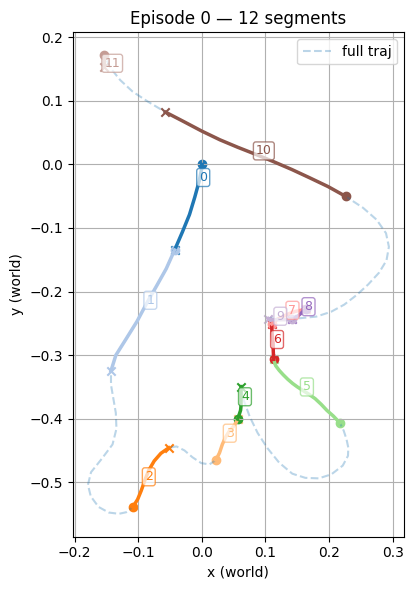

segments legth before filtering: 33
segments length after filtering: 12
segments length after direction filtering: 10


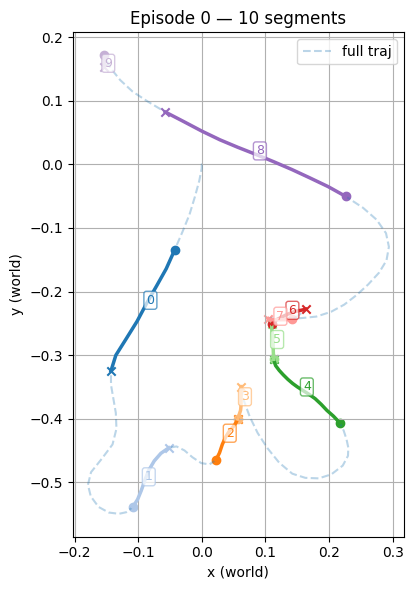

segments legth before filtering: 33
segments length after direction filtering: 31


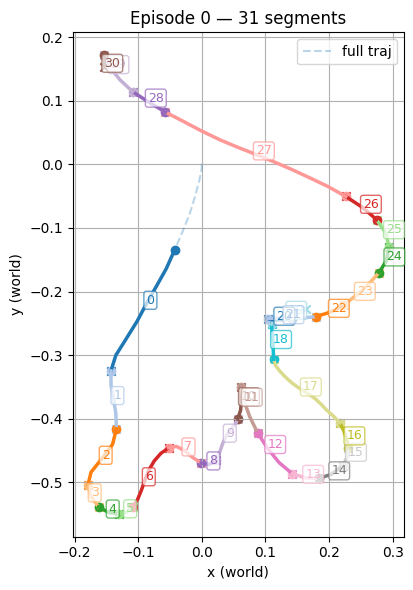

In [37]:
visualize_episode_segments(episodes_displacements, ep_idx=0, filter=False, enforce_smooth=False, eps=0.01)
visualize_episode_segments(episodes_displacements, ep_idx=0, filter=True, enforce_smooth=False, eps=0.01)
visualize_episode_segments(episodes_displacements, ep_idx=0, filter=True, enforce_smooth=True, eps=0.01)
visualize_episode_segments(episodes_displacements, ep_idx=0, filter=False, enforce_smooth=True, eps=0.01)

In [47]:
# Extract all subtrajectories from the dataset

def extract_all_subtrajectories(episodes_displacements, eps=0.01, filter=False,
                               enforce_smooth=False,
                               min_len=5,
                               min_total_disp=0.01,
                               max_angle_deg=60, use_xy_only=True):
    """
    episodes_displacements: dict[ep_idx] -> (T, 3) displacements
    eps: RDP epsilon
    use_xy_only: if True, segment in 2D (x,y) space

    returns:
      subtrajs: list of np.ndarrays of shape (L_i, D)  (displacements)
      meta:     list of dicts with episode index and time indices for each subtraj
    """
    all_subtrajs = []
    all_meta     = []

    for ep_idx, disps in episodes_displacements.items():
        T, D = disps.shape

        # Positions for RDP (2D or 3D)
        if use_xy_only:
            positions = disps_to_positions(disps[:, :2])  # (T+1, 2)
        else:
            positions = disps_to_positions(disps)          # (T+1, D)

        # 1) RDP keypoints
        key_idxs = rdp_segment_indices(positions, eps=eps)

        # 2) time segments
        segments = segments_from_key_idxs(key_idxs, T)

        if filter:
        # 3) filter small/weak segments
            segments = filter_segments(segments, disps,
                                    min_len=min_len,
                                    min_total_disp=min_total_disp)
            #print("segments length after filtering:", len(segments))

        if enforce_smooth:
            # 4) enforce direction smoothness
            final_segments = []
            for s, e in segments:
                if segment_direction_ok(disps, s, e, max_angle_deg=max_angle_deg):
                    final_segments.append((s, e))
            segments = final_segments
            print("segments length after direction filtering:", len(segments))

        # 3) collect subtrajectories
        for (s, e) in segments:
            subtraj = disps[s:e]   # (L, D)
            all_subtrajs.append(subtraj)
            all_meta.append({
                "episode": ep_idx,
                "start_t": s,
                "end_t": e
            })

    return all_subtrajs, all_meta

In [48]:
all_subtrajs, all_meta = extract_all_subtrajectories(episodes_displacements, eps=0.01, use_xy_only=True)
print(len(all_subtrajs), "subtrajectories total")
print(all_meta[0], all_subtrajs[0].shape)
print(all_subtrajs[0])

4306 subtrajectories total
{'episode': 0, 'start_t': 0, 'end_t': 7} (7, 3)
[[-2.3572918e-04  3.4655208e-05  0.0000000e+00]
 [-6.4360574e-05 -6.1379182e-03  0.0000000e+00]
 [-3.9540846e-03 -2.0067235e-02  0.0000000e+00]
 [-6.8752402e-03 -2.5126018e-02  0.0000000e+00]
 [-8.4044710e-03 -2.7647920e-02  0.0000000e+00]
 [-1.1166611e-02 -2.7437523e-02  0.0000000e+00]
 [-1.2203579e-02 -2.8329739e-02  0.0000000e+00]]
